In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import r2_score,mean_squared_error

In [11]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [19]:
print("🔄 Step 1: Loading engineering dataset...")
file_path = r"D:\5.MBA\1.0 MBA 4-SEM\4.0 Machine Learning\ML Steps\data\Pr-1\energydata.csv"
df = pd.read_csv(file_path,low_memory=False)


🔄 Step 1: Loading engineering dataset...


In [21]:
df.head()

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,City Building,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),...,Water Use (All Water Sources) (kgal),Water Use Intensity (All Water Sources) (gal/ft²),Water Required,Generation Date,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,7365,1155,Not Applicable: Standalone Property,Not Applicable: Standalone Property,No,1009970029,1009970029,1022631,1155 Avenue of the Americas,...,Not Available,Not Available,No,05/28/2020,40.756631,-73.982826,105.0,4.0,119.0,Midtown-Midtown South
1,2,8139,200,Not Applicable: Standalone Property,Not Applicable: Standalone Property,No,1013150001,1013150001,1037545,200 East 42nd St.,...,7310.6,19.02,Yes,05/28/2020,40.750698,-73.974306,106.0,4.0,88.0,Turtle Bay-East Midtown
2,3,8604,114,Not Applicable: Standalone Property,Not Applicable: Standalone Property,No,1009990019,1009990019,1022667,114 West 47th st,...,Not Available,Not Available,No,05/28/2020,40.758310,-73.982504,105.0,4.0,125.0,Midtown-Midtown South
3,4,8841,733,Not Applicable: Standalone Property,Not Applicable: Standalone Property,No,1013190047,1013190047,1037596,733 Third Avenue,...,Not Available,Not Available,No,05/28/2020,40.753074,-73.972753,106.0,4.0,90.0,Turtle Bay-East Midtown
4,5,11809,Conde Nast Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,No,1009950005,1009950005,1085682,4 Times Square,...,Not Available,Not Available,No,05/28/2020,40.756181,-73.986244,105.0,4.0,119.0,Midtown-Midtown South


In [23]:
df.columns

Index(['Order', 'Property Id', 'Property Name', 'Parent Property Id',
       'Parent Property Name', 'City Building', 'BBL - 10 digits',
       'NYC Borough, Block and Lot (BBL) self-reported',
       'NYC Building Identification Number (BIN)', 'Address 1 (self-reported)',
       'Address 2 (self reported)', 'Postal Code', 'Street Number',
       'Street Name', 'Borough', 'DOF Gross Floor Area (ft²)',
       'Self-Reported Gross Floor Area (ft²)',
       'Primary Property Type - Self Selected',
       'List of All Property Use Types at Property',
       'Largest Property Use Type',
       'Largest Property Use Type - Gross Floor Area (ft²)',
       '2nd Largest Property Use Type',
       '2nd Largest Property Use - Gross Floor Area (ft²)',
       '3rd Largest Property Use Type',
       '3rd Largest Property Use Type - Gross Floor Area (ft²)', 'Year Built',
       'Number of Buildings', 'Occupancy', 'Metered Areas (Energy)',
       'Metered Areas (Water)', 'ENERGY STAR Score', 'Source E

In [27]:
# Enforce your precise column names list to make sure everything matches exactly
df.columns=df.columns.str.strip()

In [29]:
target_col="Direct GHG Emissions (Metric Tons CO2e)"

In [53]:
# 2. CHOOSE THE TARGET AND CLUES
feature_cols=[ 'DOF Gross Floor Area (ft²)', 'Year Built', 'Number of Buildings', 'Occupancy',
    'Electricity Use - Grid Purchase (kWh)', 'Natural Gas Use (kBtu)', 
    'Fuel Oil #2 Use (kBtu)', 'Water Use (All Water Sources) (kgal)',
    'Latitude', 'Longitude']

In [55]:
df[target_col]= pd.to_numeric(df[target_col],errors='coerce')

In [57]:
# Clean the target column first
df=df.dropna(subset=[target_col])


In [63]:
# Clean all selected clue columns automatically
for col in feature_cols:
    df[col]=pd.to_numeric(df[col],errors ='coerce')

In [61]:
# Isolate X and y
X = df[feature_cols]
y = df[target_col]

# Fill missing clue values with the column average (Imputation)
X = X.fillna(X.mean())

print("\n========================= 📊 NYC BENCHMARK DATA REPORT =========================")
print(f"Target Carbon Variable (y) : {target_col}")
print(f"Total Features Loaded (X)  : {X.shape[1]} Columns")
print(f"Total Valid Rows for Model : {X.shape[0]} Buildings")
print("=================================================================================")


========================= 📊 NYC BENCHMARK DATA REPORT =========================
Target Carbon Variable (y) : Direct GHG Emissions (Metric Tons CO2e)
Total Features Loaded (X)  : 10 Columns
Total Valid Rows for Model : 28562 Buildings


🔄 Step 1: Splitting data into 80% Train and 20% Final Exam...
🔄 Step 2: Training 7 AI models simultaneously across 22849 buildings...
   ⚡ Training Standard Linear (OLS)...
   ⚡ Training LASSO Regression (L1)...
   ⚡ Training Ridge Regression (L2)...
   ⚡ Training ElasticNet (L1 + L2)...
   ⚡ Training Support Vector (SVR)...
   ⚡ Training Single Decision Tree...
   ⚡ Training Random Forest Ensemble...
   ⚡ Training Polynomial (Degree 2)...
🔄 Step 3: Evaluating final performance scoreboard...

========================= 📈 METROPOLITAN CARBON LEAGUE SCOREBOARD =========================
    Model Architecture R² Accuracy    Avg Error (RMSE)
Random Forest Ensemble      99.59%  127.10 Metric Tons
  Single Decision Tree      99.21%  177.56 Metric Tons
 Polynomial (Degree 2)      99.18%  180.30 Metric Tons
 Ridge Regression (L2)      99.18%  180.65 Metric Tons
 LASSO Regression (L1)      99.18%  180.79 Metric Tons
 Standard Linear (OLS)      99.18%  180.81 Metric Tons
  ElasticNet (L1 + L2)   

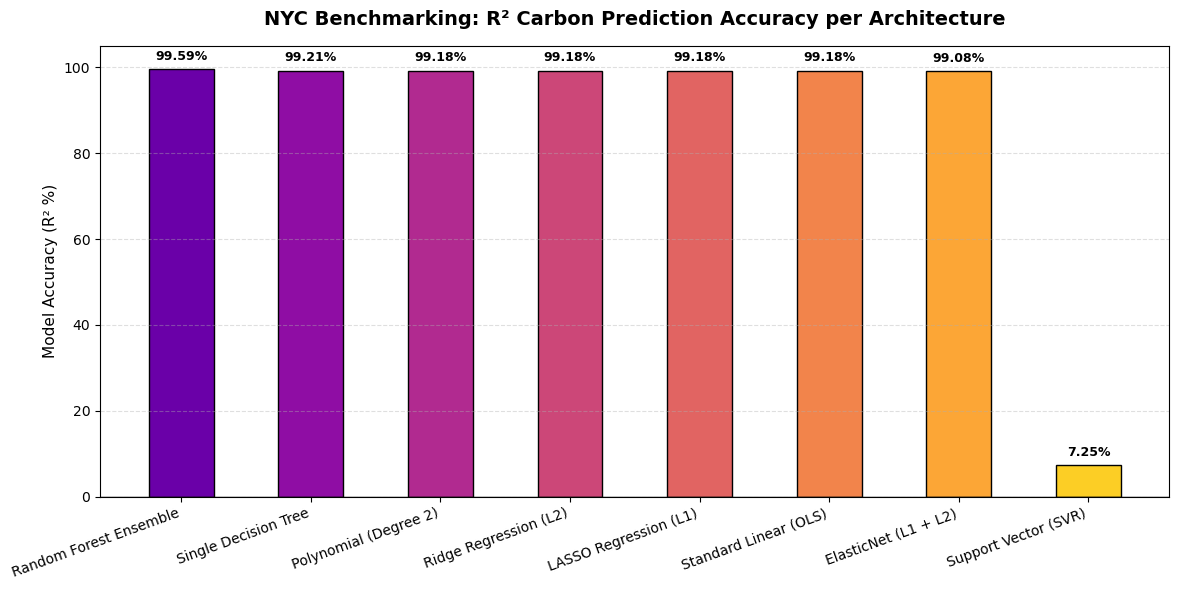

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

# Import ALL major regression algorithms
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 1. SPLIT AND SCALE THE DATA
# ==========================================
print("🔄 Step 1: Splitting data into 80% Train and 20% Final Exam...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Special non-linear transformation for Polynomial Regression
# Note: Because we have 10 columns, a 2nd degree polynomial creates a manageable number of features
poly_transform = PolynomialFeatures(degree=2)
X_train_poly = poly_transform.fit_transform(X_train_scaled)
X_test_poly = poly_transform.transform(X_test_scaled)

# ==========================================
# 2. INTENSE PIPELINE TRAINING
# ==========================================
print(f"🔄 Step 2: Training 7 AI models simultaneously across {len(X_train)} buildings...")

models = {
    "Standard Linear (OLS)": LinearRegression(),
    "LASSO Regression (L1)": Lasso(alpha=0.1, random_state=42),
    "Ridge Regression (L2)": Ridge(alpha=10.0, random_state=42),
    "ElasticNet (L1 + L2)": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    "Support Vector (SVR)": SVR(kernel='rbf', C=100.0, epsilon=0.1),
    "Single Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Ensemble": RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1) # Using 30 trees for quick execution on large volume
}

# Train all standard models
trained_predictions = {}
for name, model in models.items():
    print(f"   ⚡ Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_predictions[name] = model.predict(X_test_scaled)

# Add Polynomial Regression
print("   ⚡ Training Polynomial (Degree 2)...")
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
trained_predictions["Polynomial (Degree 2)"] = poly_model.predict(X_test_poly)

# ==========================================
# 3. COMPILING THE LEAGUE SCOREBOARD
# ==========================================
print("🔄 Step 3: Evaluating final performance scoreboard...")

scoreboard_records = []
for name, preds in trained_predictions.items():
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    scoreboard_records.append({
        "Model Architecture": name,
        "R² Accuracy": r2 * 100,  
        "Avg Error (RMSE)": rmse
    })

# Convert to DataFrame and sort by accuracy
scoreboard_df = pd.DataFrame(scoreboard_records)
scoreboard_df = scoreboard_df.sort_values(by="R² Accuracy", ascending=False).reset_index(drop=True)

# Format for clear console display
display_df = scoreboard_df.copy()
display_df["R² Accuracy"] = display_df["R² Accuracy"].map("{:.2f}%".format)
display_df["Avg Error (RMSE)"] = display_df["Avg Error (RMSE)"].map("{:.2f} Metric Tons".format)

print("\n========================= 📈 METROPOLITAN CARBON LEAGUE SCOREBOARD =========================")
print(display_df.to_string(index=False))
print("==========================================================================================")

# ==========================================
# 4. VISUAL CHART ANALYSIS
# ==========================================
plt.figure(figsize=(12, 6))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(scoreboard_df)))

bars = plt.bar(scoreboard_df["Model Architecture"], scoreboard_df["R² Accuracy"], color=colors, edgecolor='black', width=0.5)

plt.axhline(0, color='black', linewidth=1)
plt.title("NYC Benchmarking: R² Carbon Prediction Accuracy per Architecture", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Model Accuracy (R² %)", fontsize=11)
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.ylim(min(0, scoreboard_df["R² Accuracy"].min() - 5), 105)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Attach exact values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 1.5, f"{height:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [67]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# We use the exact same loading structure you just ran successfully
file_path = r"D:\5.MBA\1.0 MBA 4-SEM\4.0 Machine Learning\ML Steps\data\Pr-1\energydata.csv"
df = pd.read_csv(file_path, low_memory=False)
df.columns = df.columns.str.strip()

target_col = 'Direct GHG Emissions (Metric Tons CO2e)'
feature_cols = [
    'DOF Gross Floor Area (ft²)', 'Year Built', 'Number of Buildings', 'Occupancy',
    'Electricity Use - Grid Purchase (kWh)', 'Natural Gas Use (kBtu)', 
    'Fuel Oil #2 Use (kBtu)', 'Water Use (All Water Sources) (kgal)',
    'Latitude', 'Longitude'
]

df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col])

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

X = df[feature_cols]
y = df[target_col]
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train the winning 99.59% accurate model structure
print("🌳 Training the final production Random Forest model...")
rf_carbon = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)
rf_carbon.fit(X_train_scaled, y_train)

# Export paths matching your Resso folder environment
export_path = r"D:\5.MBA\1.0 MBA 4-SEM\4.0 Machine Learning\ML Steps\data\appliances+energy+prediction-Resso\\"

joblib.dump(scaler, export_path + 'nyc_carbon_scaler.pkl')
joblib.dump(rf_carbon, export_path + 'nyc_carbon_rf_model.pkl')

print("✅ SUCCESS: NYC Carbon Scaler and Random Forest brain successfully frozen and exported!")

🌳 Training the final production Random Forest model...
✅ SUCCESS: NYC Carbon Scaler and Random Forest brain successfully frozen and exported!
